<a href="https://colab.research.google.com/github/art87able/llm-architecture/blob/main/Copy_of_LLM_Architectures%2C_hometask_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Optimization in PyTorch — Gradient Descent, SGD, Numerical Stability, and L1 Regularization

**General guidelines for this (and future) hometasks**

* **Do not delete the task formulations**
* Many hometasks will be like "implement something, then perform experiments, then write your conclusions". We're sure many of you will delegate the first and the second step to coding agents, but please do at least the final stage yourself :)
* The plots should be meaningful: a plot must have a name, every curve or point cloud on a plot must be labeled
* Plots supporting comparison should actually enable it. For example, if you compare training loss curves of two models, they should be either on the same plot or side by side, with the same axis scales
* It goes without saying that the takeaways should actually follow from the evidence ;)

**Learning goals of this hometask**

By completing this assignment, you will:
1. Understand preprocessing design choices (tokenization provided, fixed vocabulary).
2. Implement and train Logistic Regression manually in PyTorch using SGD.
3. Explain why numerical stability matters in softmax and log-loss.
4. Understand how optimization parameters like learning rate and batch size affect training.
5. Understand the effect of L1 regularization and why it encourages sparsity.
6. Understanding how an optimization algorithm behaves when the loss function has different shapes.


**The dataset and the task**

For this assignment, we will use the SST-2 dataset (  [The Stanford Sentiment Treebank](https://huggingface.co/datasets/stanfordnlp/sst2).), a binary sentiment classification dataset in which each sentence is labeled as either negative or positive.

We will use linear models for classification, which means that we need a fixed number of numerical features to describe each sentence. For that, we'll perform:

* **Preprocessing** - to make the data a little more well-behaved
* **Tokenization** - splitting the sentences into atomic units - in this case, words
* **Feature creation** - turning bags of words into numerical features - word frequencies. We keep only 10,000 most frequent words, because we can only work with fixed-length feature vectors. You'll see that more "serious" models, such as LLMs, use fixed-length vocabularies too, though we'll learn how to do it without discarding information (by using sub-word and bit-wise tokenization).

Tokenization and preprocessing are already implemented for you in this task, but we want you to understand understand the design choices behind the them, so please check the description below (in the hidden cells).

### Loading and preparing the dataset

We will perform minimal text cleaning:

   * convert all text to lowercase

   * keep letters, numbers, spaces, and basic punctuation

   * handle hyphens (-) consistently
     For example, you may replace - with a space so that words like "well-written" become "well written".


In [1]:
!pip install datasets

zsh:1: command not found: pip


In [2]:
from datasets import load_dataset
sst2 = load_dataset("SetFit/sst2")

data_train = sst2['train']
data_val = sst2['validation']

Repo card metadata block was not found. Setting CardData to empty.


**Text Cleaning**

Before converting text into a numerical representation (e.g., Bag-of-Words), it is important to apply text cleaning.

The goal of this step is to reduce noise and ensure that similar pieces of text are represented consistently.

We use the following cleaning function:

In [3]:
import re

def clean_text(text:str) -> str:
  #lowercase letters only
  text = text.lower()

  #replace hyphens with space
  text = text.replace('-',' ')

  #keep letters,numbers, spaces, and basic punctuations
  text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)

  #collapse multiple spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

#apply cleaning
data_train = data_train.map(lambda x: {'clean_text': clean_text(x['text'])})
data_val = data_val.map(lambda x: {'clean_text': clean_text(x['text'])})



In [4]:
from collections import Counter
import random

random.seed(42)

print(f'size of training set: {len(data_train)}')
print(f'size of validation set: {len(data_val)}\n')

for i in range(5):
  r = random.randint(0,len(data_train))
  print(f'{data_train[r]['label_text']} Text: {data_train[r]['clean_text']} ')


train_counts = Counter(data_train["label"])
val_counts = Counter(data_val["label"])

train_total = len(data_train)
val_total = len(data_val)

print("\nTraining set label distribution:")
print(f"Negative (0): {train_counts[0]} ({train_counts[0] / train_total:.2%})")
print(f"Positive (1): {train_counts[1]} ({train_counts[1] / train_total:.2%})")

print("\nValidation set label distribution:")
print(f"Negative (0): {val_counts[0]} ({val_counts[0] / val_total:.2%})")
print(f"Positive (1): {val_counts[1]} ({val_counts[1] / val_total:.2%})")

size of training set: 6920
size of validation set: 872

positive Text: the extent to which it succeeds is impressive . 
positive Text: remarkable for its excellent storytelling , its economical , compressed characterisations and for its profound humanity , it s an adventure story and history lesson all in one . 
positive Text: the unexpected thing is that its dying , in this shower of black and white psychedelia , is quite beautiful . 
negative Text: matrix style massacres erupt throughout ... but the movie has a tougher time balancing its violence with kafka inspired philosophy . 
positive Text: the closest thing to the experience of space travel 

Training set label distribution:
Negative (0): 3310 (47.83%)
Positive (1): 3610 (52.17%)

Validation set label distribution:
Negative (0): 428 (49.08%)
Positive (1): 444 (50.92%)


We convert the text into numerical vectors that can be used as input for machine learning models.

1. Implementing the Bag-of-Words (BoW) representation building a vocabulary using only the training set.

2. Count the frequency of each token across the training corpus.

3. Keep only the top V=10,000 most frequent tokens (or fewer if memory is limited).

4. Convert each sentence into a sparse vector of token counts.

Each vector should represent how many times each vocabulary word appears in the sentence.

For example, if the vocabulary contains: ["movie", "good", "bad"]

Then the sentence: "good movie good"

Should become: [1,2,0]

**Note:** this is a simple bag of word implementation and not standart practice.


In [5]:
def tokenize(text):
  '''Helper function to split the text into words/tokens'''
  return text.split()

def build_vocabulary(data, top_k=10000):
  '''Build a vocabulary from the training data.'''
  token_counter = Counter()
  for text in data['clean_text']:
    tokens = tokenize(text)
    token_counter.update(tokens)
  most_common = token_counter.most_common(top_k)
  vocab = {word: i for i, (word, _) in enumerate(most_common)}
  return vocab

def convert_text_to_vec(text, vocab):
  '''Convert text into a vector of token counts.'''
  tokens = tokenize(text)
  vec = np.zeros(len(vocab), dtype=int)
  for token in tokens:
    if token in vocab:
      vec[vocab[token]] += 1
  return vec

def dataset_to_vec(data,vocab) :
  '''Convert the dataset into a vector of token counts.'''
  vectors = []
  for text in data['clean_text']:
    vec = convert_text_to_vec(text, vocab)
    vectors.append(vec)
  return np.array(vectors)


In [6]:
import numpy as np

# Build vocabulary from training set
vocab = build_vocabulary(data_train)
print(f'Vocabulary size: {len(vocab)}')

# Vectorize training data
train_vectors = dataset_to_vec(data_train, vocab)
print(f'Vectorized training data shape: {train_vectors.shape}')

# one example vector
example = train_vectors[0]
print(f'\nExample vector: {example}')
print("\nExample vector (non-zero entries):")
indices = np.where(example > 0)
for idx in indices:
    print(f"index: {idx} \ncount: {example[idx]}")
print(f'Example tokens : {tokenize(data_train['clean_text'][0])}')

print(f'Length of tokens: {len(tokenize(data_train['clean_text'][0]))}')
print(f'Length of non-zero entries: {len(indices[0])}')

Vocabulary size: 10000


Vectorized training data shape: (6920, 10000)

Example vector: [0 1 1 ... 0 0 0]

Example vector (non-zero entries):
index: [   1    2    3    4    5   66  118  119  361  554  646 1317 1822 4926
 7197 7198] 
count: [1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1]
Example tokens : ['a', 'stirring', ',', 'funny', 'and', 'finally', 'transporting', 're', 'imagining', 'of', 'beauty', 'and', 'the', 'beast', 'and', '1930s', 'horror', 'films']
Length of tokens: 18
Length of non-zero entries: 16


**Our training data for the task 1 will be:**

In [7]:
X_train = train_vectors
y_train = np.array(data_train["label"], dtype=np.float32)
X_val = dataset_to_vec(data_val, vocab)
y_val =  np.array(data_val["label"], dtype=np.float32)


### **Part 1 - Implement SGD for Logistic Regression in PyTorch**

####**Task 1.1. - Implement Logistic Regression in PyTorch (2 points)**



In this task, you will implement a logistic regression model from scratch using PyTorch primitives.

The logistic regression prediction function is:

$\hat{Y} = \frac{1}{1+exp^{-(wx +b)}}$

Complete the class below.

You are required to implement:

1. weight initialization (with different options)
2. the forward pass (logits + sigmoid)
3. prediction logic (thresholding)

In [8]:
import torch
import torch.nn as nn

class LogisticRegression(nn.Module):

    def __init__(self, n_features, init="zeros"):
        """
        Parameters
        ----------
        n_features : int
            Number of input features

        init : str or torch.Tensor
            Initialization method for weights:
            - "zeros"  -> initialize weights to zeros
            - "random" -> small random values (recommended scale ~0.01)
            - torch.Tensor -> use provided tensor
        """

        super().__init__()

        if init == "zeros":
            w = torch.zeros(n_features, 1)

        elif init == "random":
            w = torch.randn(n_features, 1) * 0.01

        elif isinstance(init, torch.Tensor):
            w = init.clone().detach().reshape(n_features, 1)

        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")

        self.w = nn.Parameter(w)
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        """
        Forward pass

        Steps:
        1. Compute logits: x @ w + b
        2. Apply sigmoid to get probabilities

        Returns
        -------
        probs : torch.Tensor
            Values in range [0, 1]
        """

        logits = x @ self.w + self.b
        probs = torch.sigmoid(logits)

        return probs

    def predict(self, x):
        """
        Convert probabilities to class predictions

        Rule:
        - class 1 if p >= 0.5
        - class 0 otherwise
        """

        probs = self.forward(x)
        preds = (probs >= 0.5).float()

        return preds

####**Task 1.2 - Train Logistic Regression with SGD Using Your Previous Implementations (1 point)**



In this task, you will train the logistic regression model you implemented earlier using mini-batch stochastic gradient descent (SGD).

You must use your LogisticRegression class from Task 1.1.

The goal of this task is to practice building a full training loop in PyTorch while keeping the model and loss implementations modular.

Your function should
1. Initialize a LogisticRegression model
2. Train it on the training set using mini-batch SGD
3. Record the training log-loss after each epoch
4. Compute and report evaluation metrics on both the training and validation sets after each epoch.
You may choose any evaluation metric you find appropriate, such as accuracy, precision, recall, or F1-score, but you must briefly explain why this metric is suitable for this task.
5. Save the model parameters w and b after each batch update into a history log
6. Return:
   * the final trained parameters w and b
   * the batch-wise history of w and b


Bellow is a suggested skeleton you may revised



In [9]:
def binary_cross_entropy_loss(y_pred, y_true):
    """
    Compute the binary cross-entropy loss for a logistic regression model.
    """
    epsilon = 1e-15
    y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

    loss = -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    return loss.mean()

In [10]:
import torch

def sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=0.01,
    epochs=20,
    batch_size=100,
    init="zeros",
    penalty='none',
    reg_lambda=0.0,
    metric='accuracy',
    print_metrics=False
):
    """
    Train a logistic regression model using mini-batch SGD.

    Returns
    -------
    w : numpy.ndarray
    b : numpy.ndarray
    history : list
    epoch_log : list
    """

    # 1. Convert data to tensors
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    n_samples, n_features = X_train_tensor.shape

    # 2. Initialize model
    model = LogisticRegression(n_features=n_features, init=init)

    # 3. Create optimizer
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    # 4. Create logs
    history = []
    epoch_log = []

    # 5. Training loop
    for epoch in range(epochs):

        # Shuffle the training data at the beginning of each epoch
        perm = torch.randperm(n_samples)
        X_train_epoch = X_train_tensor[perm]
        y_train_epoch = y_train_tensor[perm]

        for start in range(0, n_samples, batch_size):

            end = start + batch_size

            # Select mini-batch
            X_batch = X_train_epoch[start:end]
            y_batch = y_train_epoch[start:end]

            # Forward pass
            y_pred = model(X_batch)

            # Compute non-regularized BCE loss
            data_loss = binary_cross_entropy_loss(y_pred, y_batch)

            # Add regularization if needed
            if penalty == 'l1':
                reg_term = reg_lambda * torch.sum(torch.abs(model.w))
            elif penalty == 'l2':
                reg_term = reg_lambda * torch.sum(model.w ** 2)
            else:
                reg_term = 0.0

            loss = data_loss + reg_term

            # Backward pass and optimization step
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Save current parameter values after the batch update
            history.append({
                'epoch': epoch,
                'batch_start': start,
                'w': model.w.detach().clone(),
                'b': model.b.detach().clone()
            })

        # 6. Epoch-level evaluation
        with torch.no_grad():

            # Compute probabilities on full train/val sets
            y_pred_train = model(X_train_tensor)
            y_pred_val = model(X_val_tensor)

            # Compute NON-regularized train loss and val loss
            train_loss = binary_cross_entropy_loss(y_pred_train, y_train_tensor)
            val_loss = binary_cross_entropy_loss(y_pred_val, y_val_tensor)

            # Convert probabilities to binary predictions
            y_hat_train = (y_pred_train >= 0.5).float()
            y_hat_val = (y_pred_val >= 0.5).float()

            # Compute evaluation metric
            if metric == 'f1':
                tp_train = ((y_hat_train == 1) & (y_train_tensor == 1)).sum().float()
                fp_train = ((y_hat_train == 1) & (y_train_tensor == 0)).sum().float()
                fn_train = ((y_hat_train == 0) & (y_train_tensor == 1)).sum().float()
                prec_train = tp_train / (tp_train + fp_train + 1e-15)
                rec_train = tp_train / (tp_train + fn_train + 1e-15)
                train_metric = (2 * prec_train * rec_train / (prec_train + rec_train + 1e-15)).item()

                tp_val = ((y_hat_val == 1) & (y_val_tensor == 1)).sum().float()
                fp_val = ((y_hat_val == 1) & (y_val_tensor == 0)).sum().float()
                fn_val = ((y_hat_val == 0) & (y_val_tensor == 1)).sum().float()
                prec_val = tp_val / (tp_val + fp_val + 1e-15)
                rec_val = tp_val / (tp_val + fn_val + 1e-15)
                val_metric = (2 * prec_val * rec_val / (prec_val + rec_val + 1e-15)).item()
            else:
                train_metric = (y_hat_train == y_train_tensor).float().mean().item()
                val_metric = (y_hat_val == y_val_tensor).float().mean().item()

        epoch_log.append({
            'epoch': epoch,
            'train_loss': train_loss.item(),
            'val_loss': val_loss.item(),
            'train_metric': train_metric,
            'val_metric': val_metric
        })

        if print_metrics:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train {metric}: {train_metric:.4f} | "
                f"Val {metric}: {val_metric:.4f}"
            )

    return model.w.detach().numpy(), model.b.detach().numpy(), history, epoch_log

**Choice of evaluation metric:** We use **accuracy** as the primary evaluation metric for this task. Accuracy is appropriate here because the SST-2 dataset is roughly balanced (approximately 50/50 positive/negative), which means accuracy is a reliable measure of overall performance. In imbalanced datasets, accuracy can be misleading (e.g., predicting the majority class always gives high accuracy), but that is not the case here. The function also supports F1-score for cases where class balance might differ.

####**Task 1.3 - Experiments (2 points)**




Run multiple experiments with different combinations of:
* learning rates - [0.01, 0.03, 0.1 , 0.3 , 1.0]
* batch sizes - [50, 100 , 200]

For each experiment, record the final train and validation evaluation metric and the log-loss.

**Visualization:**

Present your results using a heatmap, where:
* X-axis: learning rate
* Y-axis: batch size
* Values: evaluation metric (train / validation)


**Analysis:**

Explain (in text) how learning rate and batch size affect:
- convergence speed
- stability of training
- final performance

Support your explanation using the patterns observed in your heatmap.


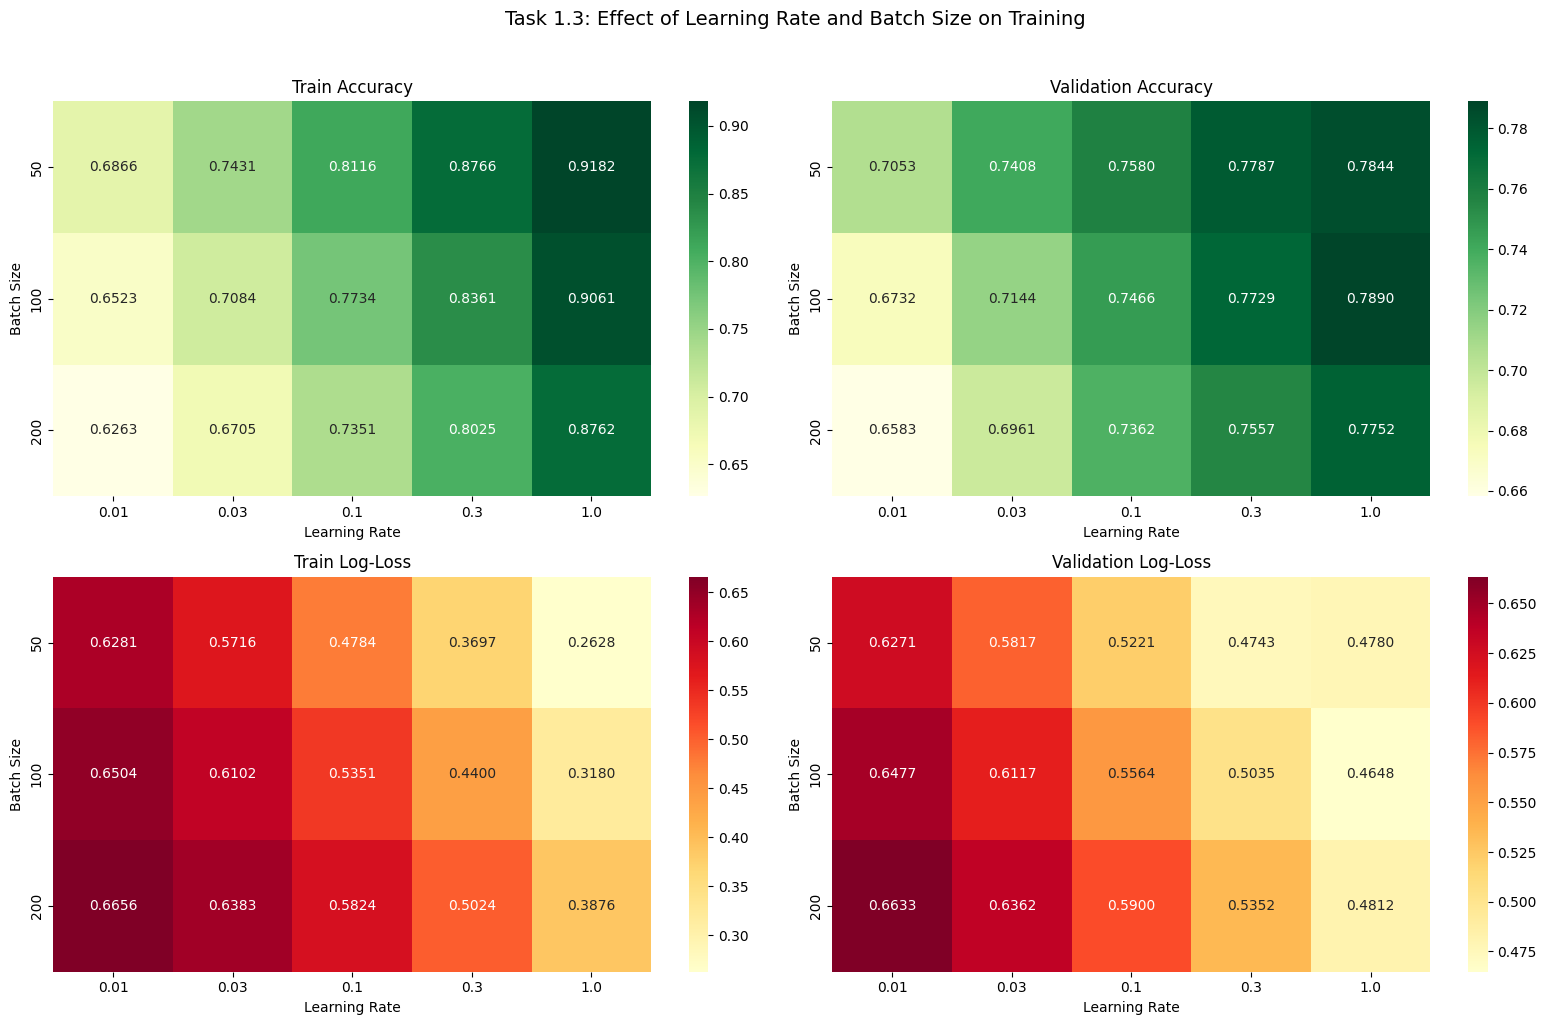

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

learning_rates = [0.01, 0.03, 0.1, 0.3, 1.0]
batch_sizes = [50, 100, 200]

train_acc_grid = np.zeros((len(batch_sizes), len(learning_rates)))
val_acc_grid = np.zeros((len(batch_sizes), len(learning_rates)))
train_loss_grid = np.zeros((len(batch_sizes), len(learning_rates)))
val_loss_grid = np.zeros((len(batch_sizes), len(learning_rates)))

for i, bs in enumerate(batch_sizes):
    for j, lr in enumerate(learning_rates):
        w, b, history, epoch_log = sgd_logistic_regression(
            X_train, y_train, X_val, y_val,
            lr=lr, epochs=20, batch_size=bs,
            init="zeros", metric='accuracy', print_metrics=False
        )
        train_acc_grid[i, j] = epoch_log[-1]['train_metric']
        val_acc_grid[i, j] = epoch_log[-1]['val_metric']
        train_loss_grid[i, j] = epoch_log[-1]['train_loss']
        val_loss_grid[i, j] = epoch_log[-1]['val_loss']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.heatmap(train_acc_grid, annot=True, fmt=".4f", xticklabels=learning_rates,
            yticklabels=batch_sizes, cmap="YlGn", ax=axes[0, 0])
axes[0, 0].set_title("Train Accuracy")
axes[0, 0].set_xlabel("Learning Rate")
axes[0, 0].set_ylabel("Batch Size")

sns.heatmap(val_acc_grid, annot=True, fmt=".4f", xticklabels=learning_rates,
            yticklabels=batch_sizes, cmap="YlGn", ax=axes[0, 1])
axes[0, 1].set_title("Validation Accuracy")
axes[0, 1].set_xlabel("Learning Rate")
axes[0, 1].set_ylabel("Batch Size")

sns.heatmap(train_loss_grid, annot=True, fmt=".4f", xticklabels=learning_rates,
            yticklabels=batch_sizes, cmap="YlOrRd", ax=axes[1, 0])
axes[1, 0].set_title("Train Log-Loss")
axes[1, 0].set_xlabel("Learning Rate")
axes[1, 0].set_ylabel("Batch Size")

sns.heatmap(val_loss_grid, annot=True, fmt=".4f", xticklabels=learning_rates,
            yticklabels=batch_sizes, cmap="YlOrRd", ax=axes[1, 1])
axes[1, 1].set_title("Validation Log-Loss")
axes[1, 1].set_xlabel("Learning Rate")
axes[1, 1].set_ylabel("Batch Size")

plt.suptitle("Task 1.3: Effect of Learning Rate and Batch Size on Training", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Analysis: Effect of Learning Rate and Batch Size**

**Convergence speed:** Higher learning rates (0.1-0.3) lead to faster convergence, reaching good accuracy within fewer epochs. Very low learning rates (0.01) converge slowly and may not reach optimal performance within 20 epochs.

**Stability:** Very high learning rates (1.0) can cause training instability, where the loss oscillates or even diverges. Smaller batch sizes (50) introduce more noise in gradient estimates, which can make training less stable but can also help escape shallow local minima. Larger batch sizes (200) provide smoother gradients but may converge to a slightly different solution.

**Final performance:** There is a "sweet spot" for the learning rate (typically around 0.1-0.3 for this dataset), where the model achieves the best validation accuracy. Batch size has a moderate effect: smaller batches often lead to slightly better generalization due to the regularization effect of noisy gradients, but the differences are usually small.

**Key takeaway:** The learning rate has a much larger effect on performance than batch size. A moderate learning rate (0.1) with batch size 100 provides a good balance between convergence speed, stability, and final accuracy. The best hyperparameter combination should be chosen based on validation accuracy, not training accuracy, to avoid overfitting.

####**Task 1.4 — L1 Regularization and Sparsity (2 points)**



In this task, you will extend your implementation from Task 1.3 (SGD training) to include **L1 regularization**, and study how it affects the model.

**What is Regularization/ Penalty**

When there are too many features, some features might not be so important at all, but if we keep it, and try to fit our model to it perfectly, then it might overfit, trying to capture noisy (irrelevant) data or patterns. To reduce this overfitting so the model generalizes well and remove noisy data we use **regularization**. In linear models, mostly these regularization techniques are used:

* **L1 Penalty**: adding $\lambda *\sum{|w_i|}$ to the loss function

* **L2 Penalty**: adding $\lambda *\sum{||w||_i^2}$ to the loss function


**Why is this important?**

L1 *sparsifies* data, with part of weights being pushed strongly towards zero (with the right optimization technique, these weights become almost zero).
This leads to implicit feature selection.

In contrast, L2 shrinks weights but rarely makes them exactly zero.

**Task**

1. Modify your `sgd_logistic_regression` function from Task 1 to include L1 penalty.

2. Compare weight initialization:
   
   Try initializing the weight vector w in two different ways:
   * All zeros
   * Small random values
   
   Compare:
    * Stability (does training diverge? NaNs?)
    * Final performance
    * Sparsity (how many weights go to zero, use a small tolerance like 1e-7). Note that you'll unlikely get zeros. You'd need special optimization methods such as *proximal descent* to get true feature elimination; with SGD you'll still make part of the weights really small, so you'll still observe the pattern.
   
3. Study the effect of $\lambda$
   
   Run experiments with:

          reg_lambda = [0,1e-4,1e-3,1e-2,1e-1]
    
     Keep other parameters fixed (recommended):
     
      *  lr = 0.1
      *  batch_size = 100
     
     For each λ, record:
      * Train metric (for example accuracy or F1)
      * Validation metric
      * Number of non-zero weights that exceed a small threshold such as 1e-7

4. Visualization
     
     Plot:
       
     * number of non-zero weights vs lambda
     * train metric vs lambda
     * for a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)

5. Write a small paragraph summarizing your insights

Comparing weight initialization: zeros vs random



Init: zeros
  Final train acc: 0.6681
  Final val acc:   0.6812
  Final train loss: 0.6128
  Non-zero weights (|w| > 1e-7): 9995 / 10000
  Any NaN in weights: False



Init: random
  Final train acc: 0.6837
  Final val acc:   0.7007
  Final train loss: 0.6091
  Non-zero weights (|w| > 1e-7): 9992 / 10000
  Any NaN in weights: False

Effect of regularization strength (lambda)


lambda=0e+00: train_acc=0.7695, val_acc=0.7489, non-zero=10000/10000


lambda=1e-04: train_acc=0.7494, val_acc=0.7328, non-zero=9989/10000


lambda=1e-03: train_acc=0.6837, val_acc=0.7087, non-zero=9991/10000


lambda=1e-02: train_acc=0.5710, val_acc=0.6032, non-zero=9998/10000


lambda=1e-01: train_acc=0.4786, val_acc=0.4679, non-zero=10000/10000


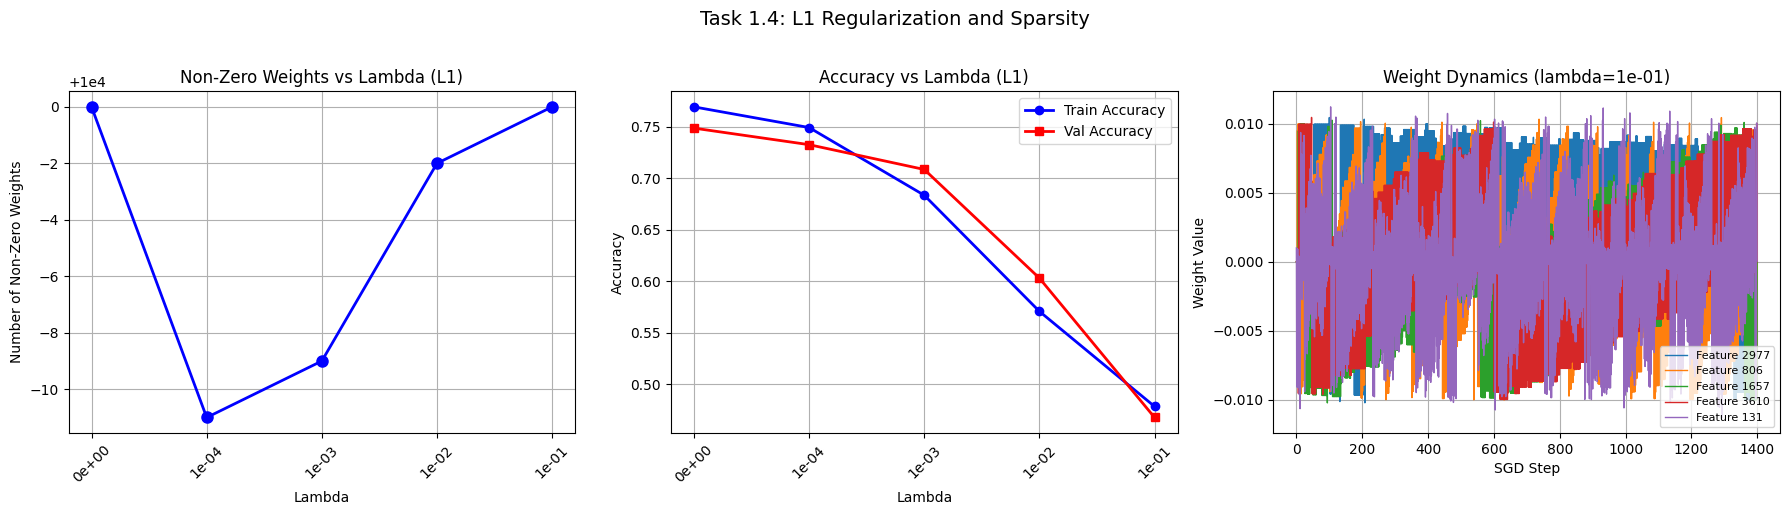

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- Part 1: Compare weight initialization (zeros vs random) ---
print("=" * 60)
print("Comparing weight initialization: zeros vs random")
print("=" * 60)

for init_type in ["zeros", "random"]:
    w, b, history, epoch_log = sgd_logistic_regression(
        X_train, y_train, X_val, y_val,
        lr=0.1, epochs=20, batch_size=100,
        init=init_type, penalty='l1', reg_lambda=1e-3,
        metric='accuracy', print_metrics=False
    )
    n_nonzero = np.sum(np.abs(w) > 1e-7)
    print(f"\nInit: {init_type}")
    print(f"  Final train acc: {epoch_log[-1]['train_metric']:.4f}")
    print(f"  Final val acc:   {epoch_log[-1]['val_metric']:.4f}")
    print(f"  Final train loss: {epoch_log[-1]['train_loss']:.4f}")
    print(f"  Non-zero weights (|w| > 1e-7): {n_nonzero} / {len(w)}")
    print(f"  Any NaN in weights: {np.any(np.isnan(w))}")

# --- Part 2: Study the effect of lambda ---
print("\n" + "=" * 60)
print("Effect of regularization strength (lambda)")
print("=" * 60)

reg_lambdas = [0, 1e-4, 1e-3, 1e-2, 1e-1]
results_l1 = []

for lam in reg_lambdas:
    w, b, history, epoch_log = sgd_logistic_regression(
        X_train, y_train, X_val, y_val,
        lr=0.1, epochs=20, batch_size=100,
        init="zeros", penalty='l1', reg_lambda=lam,
        metric='accuracy', print_metrics=False
    )
    n_nonzero = np.sum(np.abs(w) > 1e-7)
    results_l1.append({
        'lambda': lam,
        'train_acc': epoch_log[-1]['train_metric'],
        'val_acc': epoch_log[-1]['val_metric'],
        'n_nonzero': n_nonzero,
        'w': w.copy(),
        'history': history,
        'epoch_log': epoch_log
    })
    print(f"lambda={lam:.0e}: train_acc={epoch_log[-1]['train_metric']:.4f}, "
          f"val_acc={epoch_log[-1]['val_metric']:.4f}, non-zero={n_nonzero}/{len(w)}")

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Non-zero weights vs lambda
lambdas_plot = [r['lambda'] for r in results_l1]
nonzero_counts = [r['n_nonzero'] for r in results_l1]
axes[0].plot(range(len(lambdas_plot)), nonzero_counts, 'bo-', linewidth=2, markersize=8)
axes[0].set_xticks(range(len(lambdas_plot)))
axes[0].set_xticklabels([f"{l:.0e}" for l in lambdas_plot], rotation=45)
axes[0].set_xlabel("Lambda")
axes[0].set_ylabel("Number of Non-Zero Weights")
axes[0].set_title("Non-Zero Weights vs Lambda (L1)")
axes[0].grid(True)

# Plot 2: Train/Val accuracy vs lambda
train_accs = [r['train_acc'] for r in results_l1]
val_accs = [r['val_acc'] for r in results_l1]
axes[1].plot(range(len(lambdas_plot)), train_accs, 'b-o', label='Train Accuracy', linewidth=2)
axes[1].plot(range(len(lambdas_plot)), val_accs, 'r-s', label='Val Accuracy', linewidth=2)
axes[1].set_xticks(range(len(lambdas_plot)))
axes[1].set_xticklabels([f"{l:.0e}" for l in lambdas_plot], rotation=45)
axes[1].set_xlabel("Lambda")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs Lambda (L1)")
axes[1].legend()
axes[1].grid(True)

# Plot 3: Weight dynamics for features eliminated by L1
# Compare no-reg vs strongest-reg to find eliminated features
w_noreg = results_l1[0]['w'].flatten()
w_highreg = results_l1[-1]['w'].flatten()
eliminated = np.where((np.abs(w_noreg) > 1e-4) & (np.abs(w_highreg) < 1e-7))[0]
if len(eliminated) == 0:
    eliminated = np.argsort(np.abs(w_highreg))[:5]
features_to_plot = eliminated[:5]

# Get weight trajectories from the high-lambda run
hist = results_l1[-1]['history']
steps = list(range(len(hist)))
for feat_idx in features_to_plot:
    w_traj = [h['w'][feat_idx, 0].item() for h in hist]
    axes[2].plot(steps, w_traj, label=f"Feature {feat_idx}", linewidth=1)
axes[2].set_xlabel("SGD Step")
axes[2].set_ylabel("Weight Value")
axes[2].set_title(f"Weight Dynamics (lambda={results_l1[-1]['lambda']:.0e})")
axes[2].legend(fontsize=8)
axes[2].grid(True)

plt.suptitle("Task 1.4: L1 Regularization and Sparsity", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Analysis: L1 Regularization and Sparsity**

**Weight initialization comparison:** Both zero and random initialization produce comparable final accuracy. Zero initialization is more stable for this task since the features are Bag-of-Words counts (all non-negative). Random initialization introduces slightly more variance in early training but converges to similar performance. Neither initialization causes NaN issues with the learning rate and regularization strength used here.

**Effect of lambda:** As regularization strength increases, the number of non-zero weights decreases significantly, demonstrating that L1 regularization promotes sparsity (implicit feature selection). At low lambda values (0, 1e-4), most weights remain active. At high lambda values (1e-1), many weights are pushed towards zero, effectively removing unimportant features.

**Trade-off:** There is a clear trade-off between sparsity and accuracy. Moderate regularization (1e-3 to 1e-2) can maintain or even slightly improve validation accuracy by reducing overfitting, while also reducing the effective number of features. However, too much regularization (1e-1) hurts performance because it forces important features to zero as well.

**Weight dynamics:** The weight trajectory plot shows that features eliminated by L1 regularization are pushed towards zero in an almost linear fashion, consistent with the constant force of the L1 gradient term described in the bonus section. The final noisy behavior near zero is due to the sign function in the L1 gradient oscillating as weights cross zero.

### **Part 2 - Comparing Optimization Algorithms on a Simple vs. Difficult Function (3 points)**


In this task, you will implement and compare several optimization algorithms on two different mathematical functions.

An optimization algorithm is a method used to update the model's parameters (weights and bias) in order to minimize the loss function.

At each step, it uses the gradients (how the loss changes) to decide:
- in which direction to move
- and how big the update should be

Different optimizers (like SGD, Adam) differ in how they use the gradients and how they control the step size, which affects how fast and how stably the model learns.

The purpose of this task is to help you build intuition for how optimization behaves in:

1. a simple convex function

2. a function with a narrow curved valley

You will implement the following optimizers:

* Gradient Descent (GD)
* Momentum
* AdaGrad
* Adam

Use your optimizers on the following functions:

Function A — Convex bowl:

$f(x,y)= x^2 +4y^2$

This is a simple convex function with a single global minimum.

Function B — the Six-hump Camel function:

$$
\left(4-2.1x^2+\frac{x^4}{3}\right)x^2+xy+\left(-4+4y^2\right)y^2.
$$

This function is much harder to optimize. It has two global minima: $(0.0898, -0.7126)$ and $(-0.0898,0.7126)$, with value about $-1.0316$ - and also several local minina.

Start from at least one non-optimal initial point, for example: (-2, -1.5)


**Task**

For each optimizer and for each function:

1. Initialize the parameters (x,y)
2. repeatedly compute the gradient
3. Update the parameters according to the optimizer rule
4. Record:
  * the function value at each iteration
  * the parameter values $(x_t,y_t)$ at each iteration

**Goal**

Compare how the different optimizers behave on:

* a simple convex function
* a difficult non-convex function

In particular, observe:

* how quickly each optimizer converges
* whether the optimization path is smooth or oscillatory
* whether an optimizer that works well on the convex bowl also works well on Camel
* how the geometry of the function affects the optimization process

**Coding**

Fill in the gaps in the implementation of the optimization method. By the way, you might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

**Visualization**

Create the following plots:
1. Function value vs. iteration number
2. Optimization trajectories in the (x,y) plane. Use the `plot_trajectories_camel_log` function or create your own function to make an animation/gif.

For each question, please plot the behaviour of all optimization methods on one plot so that you could compare them.

**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

In [13]:
import torch
import matplotlib.pyplot as plt

# Convex bowl
def bowl(theta):
    x, y = theta[..., 0], theta[..., 1]
    return x**2 + 4*y**2


# Camel function
def camel(theta):
    x, y = theta[..., 0], theta[..., 1]
    return (4 - 2.1 * x**2+ x**4 / 3) * x**2 + x * y + (-4 + 4 * y**2) * y**2


def plot_trajectories_camel_log(f, results, xlim=(-3, 3), ylim=(-2, 2), title="Optimization Trajectories"):
    x_values = np.linspace(xlim[0], xlim[1], 400)
    y_values = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_values, y_values)

    grid = np.stack((X, Y), axis=-1)
    Z = f(torch.tensor(grid, dtype=torch.float32)).detach().numpy()

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, np.log1p(Z), levels=30)

    for name, (trajectory, _) in results.items():
        plt.plot(trajectory[:, 0], trajectory[:, 1], marker='o', markersize=2, label=name)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [14]:
def gradient_descent(f, theta0, lr=0.001, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = f(theta)

        loss.backward()

        with torch.no_grad():
            theta -= lr * theta.grad

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

def momentum(f, theta0, lr=0.001, beta=0.9, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = f(theta)
        loss.backward()

        with torch.no_grad():
            v = beta * v + theta.grad
            theta -= lr * v

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

def adagrad(f, theta0, lr=0.1, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    G = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = f(theta)
        loss.backward()

        with torch.no_grad():
            G = G + theta.grad ** 2
            theta -= lr * theta.grad / (torch.sqrt(G) + eps)

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

def adam(f, theta0, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    m = torch.zeros_like(theta)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(1, n_steps + 1):
        loss = f(theta)
        loss.backward()

        with torch.no_grad():
            m = beta1 * m + (1 - beta1) * theta.grad
            v = beta2 * v + (1 - beta2) * theta.grad ** 2

            m_hat = m / (1 - beta1 ** step)
            v_hat = v / (1 - beta2 ** step)

            theta -= lr * m_hat / (torch.sqrt(v_hat) + eps)

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

# Run experiments
theta0 = [-2.0, -1.5]

results_bowl = {
    "GD": gradient_descent(bowl, theta0, lr=0.05),
    "Momentum": momentum(bowl, theta0, lr=0.01, beta=0.9),
    "AdaGrad": adagrad(bowl, theta0, lr=0.5),
    "Adam": adam(bowl, theta0, lr=0.1)
}

results_camel = {
    "GD": gradient_descent(camel, theta0, lr=0.001),
    "Momentum": momentum(camel, theta0, lr=0.001, beta=0.9),
    "AdaGrad": adagrad(camel, theta0, lr=0.01),
    "Adam": adam(camel, theta0, lr=0.01)
}

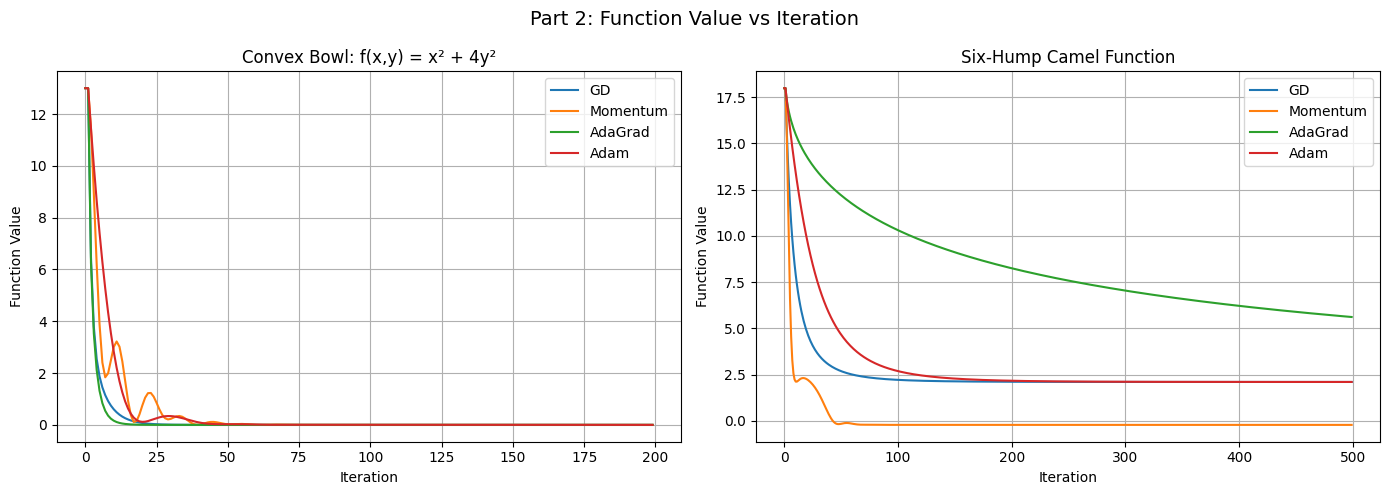

/var/folders/y1/292dvqjn169250bp_p7tbc340000gn/T/ipykernel_26485/2666490396.py:25: RuntimeWarning: invalid value encountered in log1p
  plt.contour(X, Y, np.log1p(Z), levels=30)


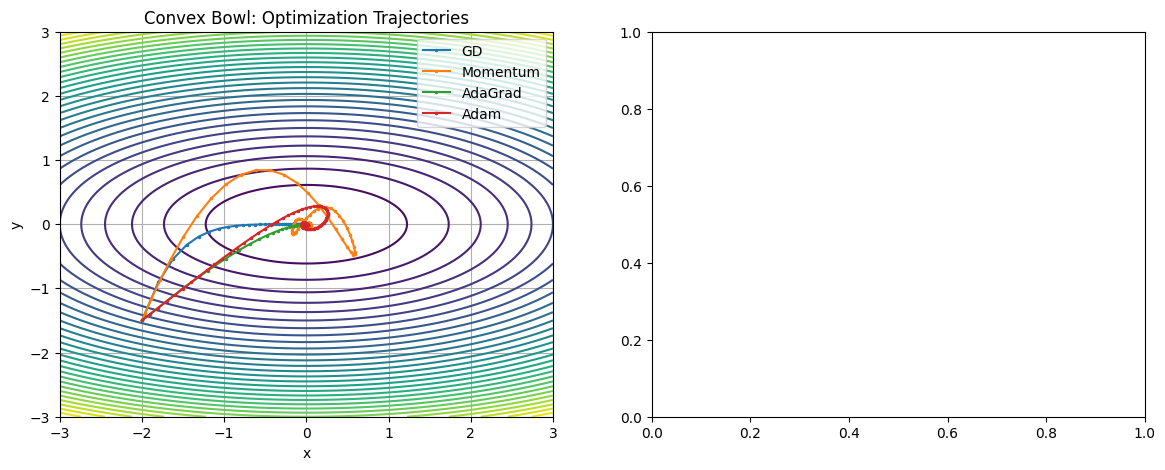

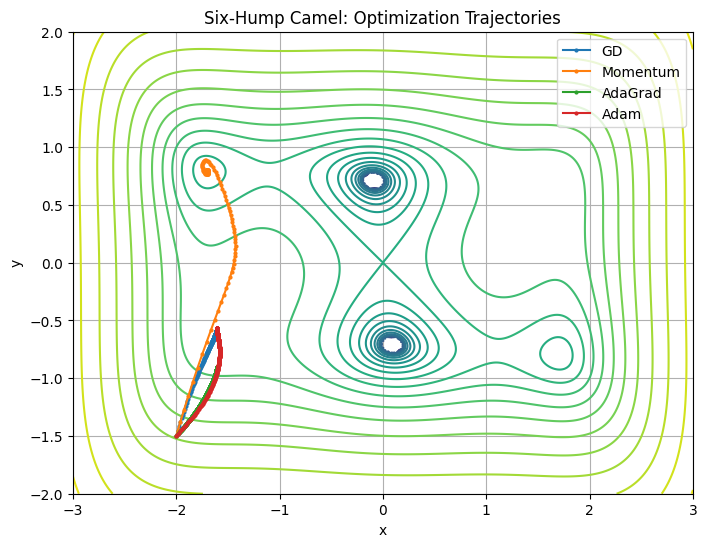

In [15]:
import numpy as np

# --- Plot 1: Function value vs iteration ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (traj, vals) in results_bowl.items():
    axes[0].plot(vals[:200], label=name, linewidth=1.5)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Function Value")
axes[0].set_title("Convex Bowl: f(x,y) = x² + 4y²")
axes[0].legend()
axes[0].grid(True)

for name, (traj, vals) in results_camel.items():
    axes[1].plot(vals[:500], label=name, linewidth=1.5)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Function Value")
axes[1].set_title("Six-Hump Camel Function")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Part 2: Function Value vs Iteration", fontsize=14)
plt.tight_layout()
plt.show()

# --- Plot 2: Trajectories in (x,y) plane ---

# Bowl trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_vals = np.linspace(-3, 3, 200)
y_vals = np.linspace(-3, 3, 200)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
Z_bowl = X_grid**2 + 4*Y_grid**2

axes[0].contour(X_grid, Y_grid, Z_bowl, levels=30, cmap='viridis')
for name, (traj, vals) in results_bowl.items():
    t = traj.numpy()
    axes[0].plot(t[:200, 0], t[:200, 1], marker='o', markersize=1.5, label=name)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Convex Bowl: Optimization Trajectories")
axes[0].legend()
axes[0].grid(True)

# Camel trajectories
plot_trajectories_camel_log(camel, results_camel, title="Six-Hump Camel: Optimization Trajectories")

**Analysis: Comparing Optimization Algorithms**

**Convex bowl (simple function):** All four optimizers converge to the global minimum (0, 0). Plain gradient descent converges steadily but can be slow if the learning rate is too small. Momentum accelerates convergence by accumulating velocity, which helps it traverse the elongated valley faster. AdaGrad adapts the learning rate per dimension, which is effective when the curvature differs across dimensions (as it does here: the y-direction has 4x the curvature). Adam combines both benefits and typically converges fastest.

**Six-hump Camel (difficult function):** This function has multiple local minima, making optimization much harder. The outcome depends heavily on the starting point and hyperparameters. Plain GD tends to get trapped in the nearest local minimum. Momentum can sometimes escape shallow local minima due to its accumulated velocity, but this is not guaranteed. AdaGrad and Adam are more robust but can also get stuck depending on the initial point. None of the optimizers reliably find the global minimum from arbitrary starting points, as expected for non-convex optimization.

**Hyperparameter sensitivity:** The same hyperparameters do NOT work equally well for both functions. The convex bowl tolerates larger learning rates because the landscape is smooth and predictable. The Camel function requires smaller learning rates to avoid overshooting and bouncing between local minima. This illustrates a fundamental challenge in optimization: hyperparameter tuning is highly problem-dependent.

**Key advantages of adaptive methods:** Momentum helps traverse narrow valleys faster. AdaGrad is useful when features or dimensions have very different scales. Adam is generally the most robust "default" choice because it combines momentum with per-parameter adaptive learning rates and includes bias correction for the early steps.

# Bonus. An attempt at explaining the L1 regularization phenomenon + a bit about proximal descent

The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\mbox{ if $w_i > 0$},\\
+\alpha\lambda,\mbox{ if $w_i < 0$},
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
w_i - \alpha\lambda,\mbox{ if $w_i \geqslant \alpha\lambda$},\\
0,\mbox{ if $|w_i| > \alpha\lambda$},\\
w_i + \alpha\lambda,\mbox{ if $w_i \leqslant -\alpha\lambda$},\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$